In [8]:
import XGBoost_XAI
import os
import pandas as pd
import numpy as np
import importlib

# Preparation of the data

In [2]:
notebook_path = "C:/Users/maria/Code/master/xai-synthetic-health/notebooks/"
dataset_path = "C:/Users/maria/OneDrive - Maastricht University/Maria Diez Perez/datasets/"
feature_imp_folder = "xai"
synthetic_folder = "syn"
num_top = 30

#### Read the datasets:

In [5]:
# Non preprocessed dataset
non_pre_dataset = pd.read_csv(os.path.join(dataset_path, 'icu_dka_dataset_20250723.csv'))
non_pre_dataset['min/max'] = np.where(
    (non_pre_dataset['osmolality_min'].isna()) |
    (non_pre_dataset['osmolality_max'].isna()) |
    (non_pre_dataset['osmolality_min'] == 0) |
    (non_pre_dataset['osmolality_max'] == 0),
    np.nan,
    non_pre_dataset['osmolality_min'] / non_pre_dataset['osmolality_max']
)

In [6]:
# Preprocessed dataset (imputed)
pre_dataset = pd.read_csv(os.path.join(dataset_path, 'imputed_dataset_0.csv'))
pre_dataset['min/max'] = pre_dataset['osmolality_min'] / pre_dataset['osmolality_max']

In [7]:
# 30 important features from the paper
paper_features = [
    'apsiii', 'lactate_max', 'age', 'sofa', 'urineoutput', 'creatinine_max', 'wbc_max', 'bun_max', 'min/max',
    'temperature_max', 'calcium_max', 'chloride_max', 'los', 'ph_max', 'mbp_min', 'weight', 'hemoglobin_min',
    'platelet_min', 'osmolality_min', 'sodium_max', 'potassium_max', 'calcium_min', 'osmolality_max',
    'resp_rate_max', 'glucose_max', 'heart_rate_max', 'ph_min', 'vasopressor', 'cardiac_disease',
    'osmolality_initial']

# min/max, the ratio of the minimum and maximum plasma osmolality; ‘I’_max, maximum body temperature; map_min

In [9]:
# Real data with shap feature importance
real_shap_30 = pd.read_csv(os.path.join(dataset_path, 'shap_30_important_features_icu_dka_dataset.csv'))
syn_shap_030 = pd.read_csv("C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/syn_data_shap_030.csv")
syn_shap_015 = pd.read_csv("C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/syn_data_shap_015.csv")
syn_shap_1 = pd.read_csv("C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/syn_data_shap_1.csv")
# This is fixed, all features. Previously 1 feature was missing.
# No race feature in the synthetic datasets 
# syn_shap_0 = pd.read_csv("C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/syn_data_shap_e1000_bs750_xaiSHAP_beta0_13-11T00.04.49.csv")
syn_shap_None = pd.read_csv("C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/syn_data_shap_nr.csv")
syn_shap_nr_5 = pd.read_csv("C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/syn_data_shap_nr_5.csv")

### RUN XGBOOST AND GET FEATURE IMPORTANCES

#### Real data 30 features based on SHAP

----------- REAL DATA SHAP FEATURES 30: Getting feature importance...-----------
Num of train data: 1099. Num of test data: 472
Train Outcome: in_hospital_death
0    1041
1      58
Name: count, dtype: int64
Test Outcome: in_hospital_death
0    447
1     25
Name: count, dtype: int64
Training XGBoost model...
Model trained successfully.
Evaluating model...
Accuracy: 0.95
Sensitivity: 0.44
Specificity: 0.98
True Negative: 439 False Positive: 8 False Negative: 14 True Positive: 11
AUC: 0.89
AUPRC (Average Precision): 0.51
Precision: 0.58
F1 Score: 0.50


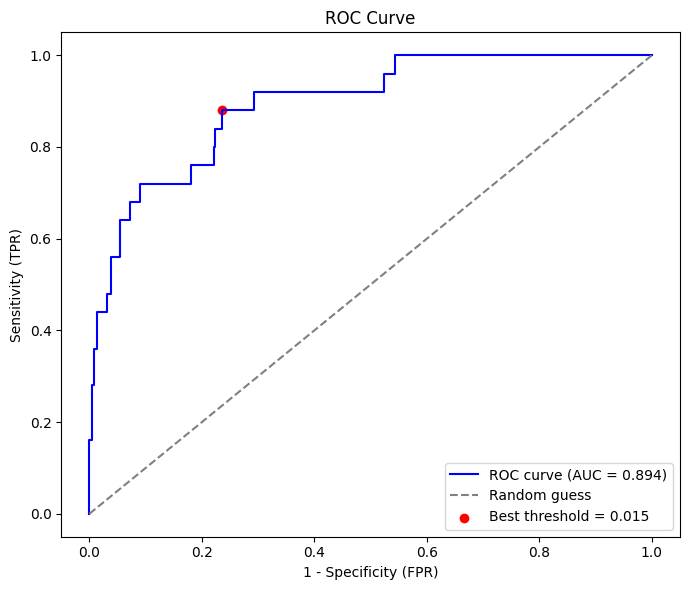

Optimal Threshold: 0.015
Accuracy: 0.77
Sensitivity: 0.88
Specificity: 0.77
True Negative: 342 False Positive: 105 False Negative: 3 True Positive: 22
Precision: 0.17
F1 Score: 0.29


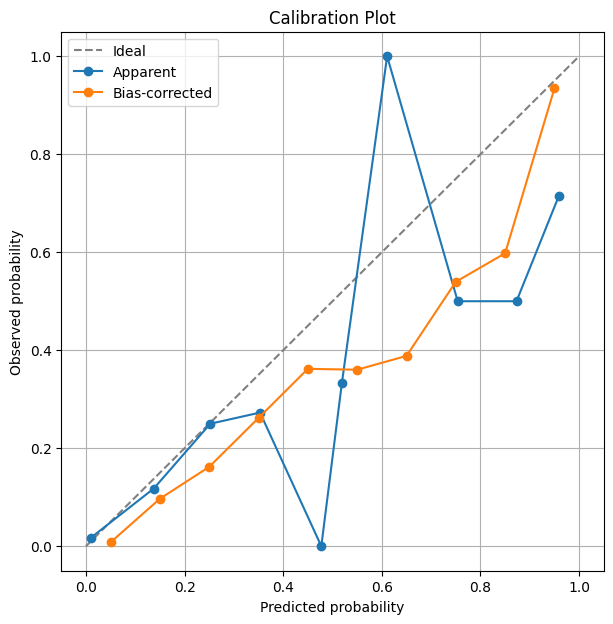

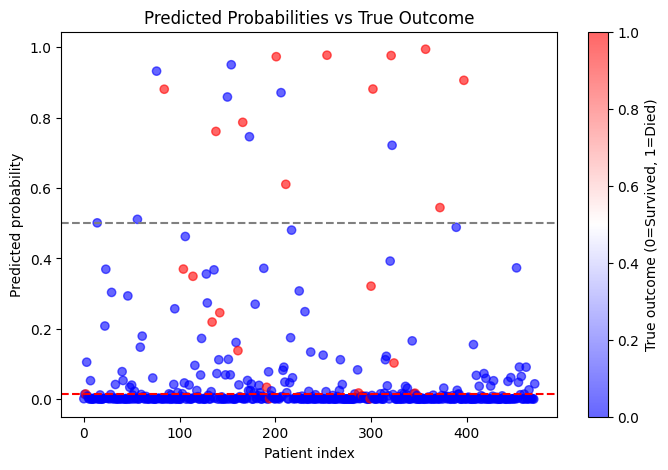

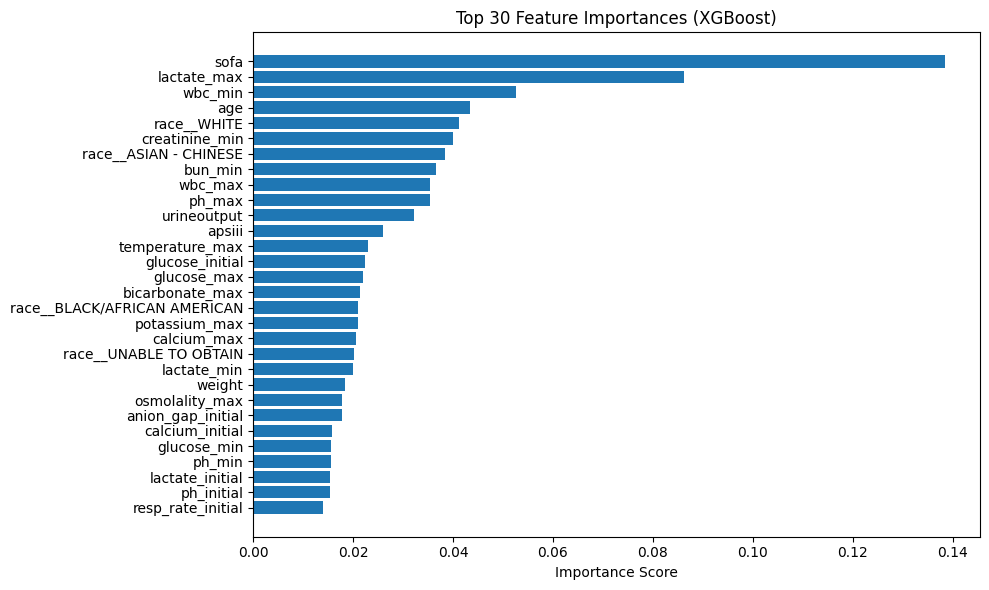

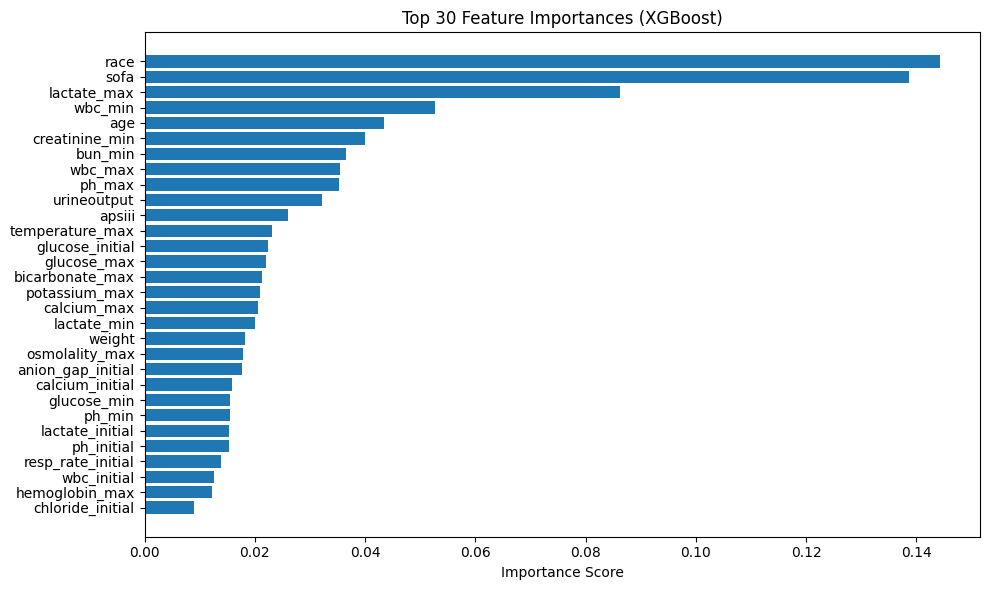

Feature importance plot saved
Genarating SHAP explanations...
SHAP explanations generated and saved.
Generating LIME explanations...
Skipping LIME (found NaNs).


In [14]:

importlib.reload(XGBoost_XAI)
real_shap_30 = pd.read_csv(os.path.join(dataset_path, 'shap_30_important_features_icu_dka_dataset.csv'))
print("----------- REAL DATA SHAP FEATURES 30: Getting feature importance...-----------")
feat_imp_real, feat_imp_gp_real, feat_imp_shap_real, feat_imp_shap_gr_real = XGBoost_XAI.run_experiment(
    train_data=real_shap_30,
    out_dir="C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/img/real_shap_30/",
    exp_name='real_shap_30'
)

#### Synthetic data, without SHAP penalty

----------- SYNTHETIC DATA NO SHAP, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------
Num of train data: 1099. Num of test data: 472
Train Outcome: in_hospital_death
0    850
1    249
Name: count, dtype: int64
Test Outcome: in_hospital_death
0    365
1    107
Name: count, dtype: int64
Training XGBoost model...
Model trained successfully.
Evaluating model...
Accuracy: 0.69
Sensitivity: 0.23
Specificity: 0.82
True Negative: 299 False Positive: 66 False Negative: 82 True Positive: 25
AUC: 0.51
AUPRC (Average Precision): 0.25
Precision: 0.27
F1 Score: 0.25


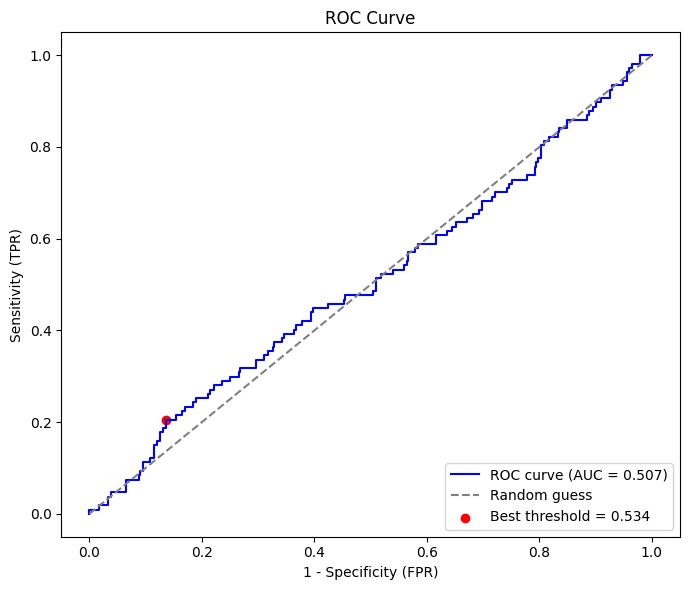

Optimal Threshold: 0.534
Accuracy: 0.71
Sensitivity: 0.21
Specificity: 0.86
True Negative: 315 False Positive: 50 False Negative: 85 True Positive: 22
Precision: 0.31
F1 Score: 0.25


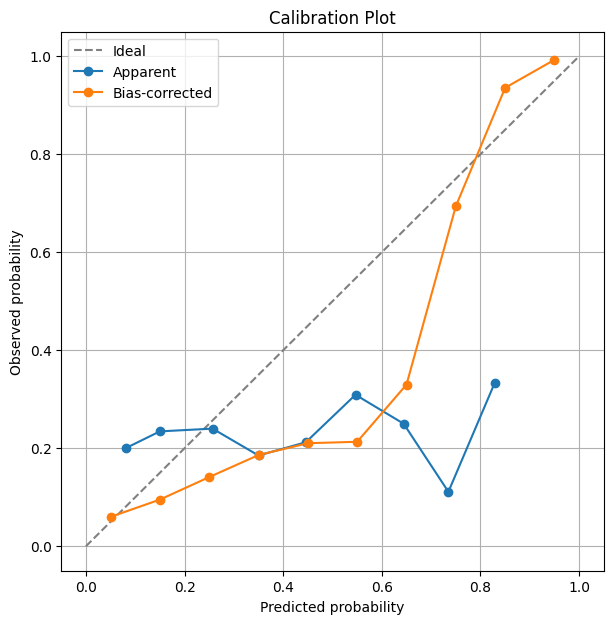

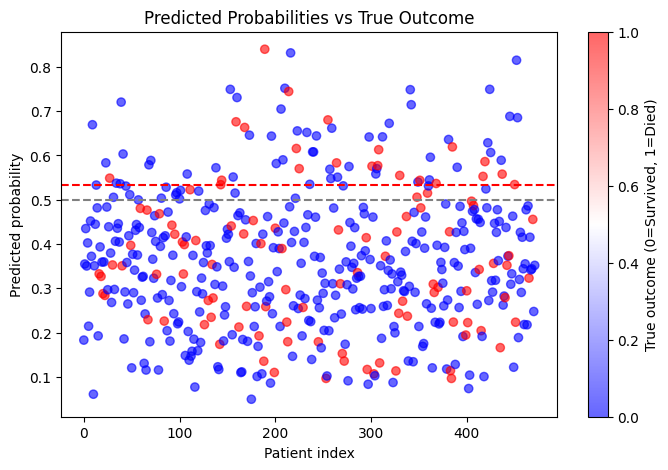

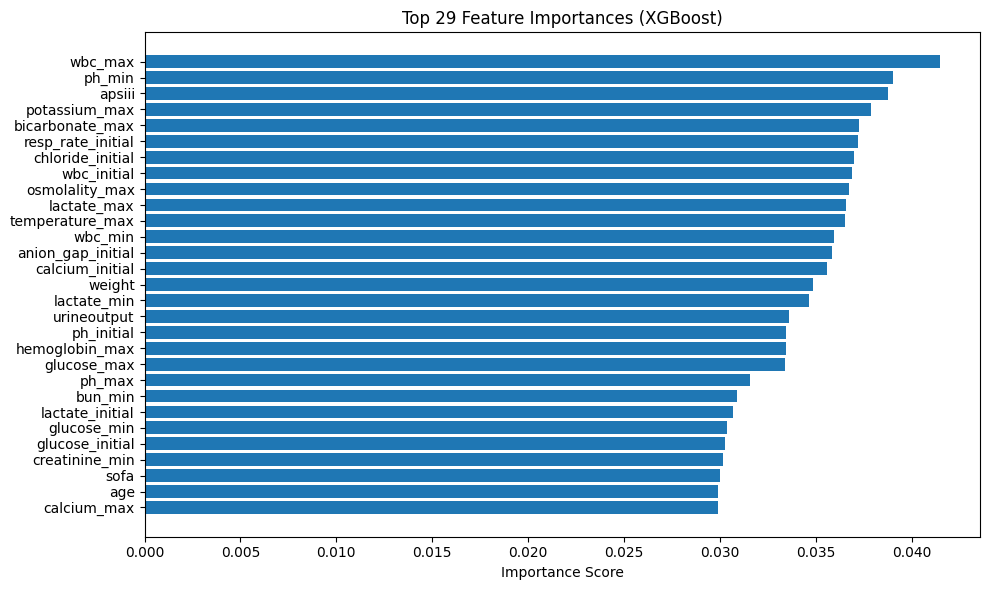

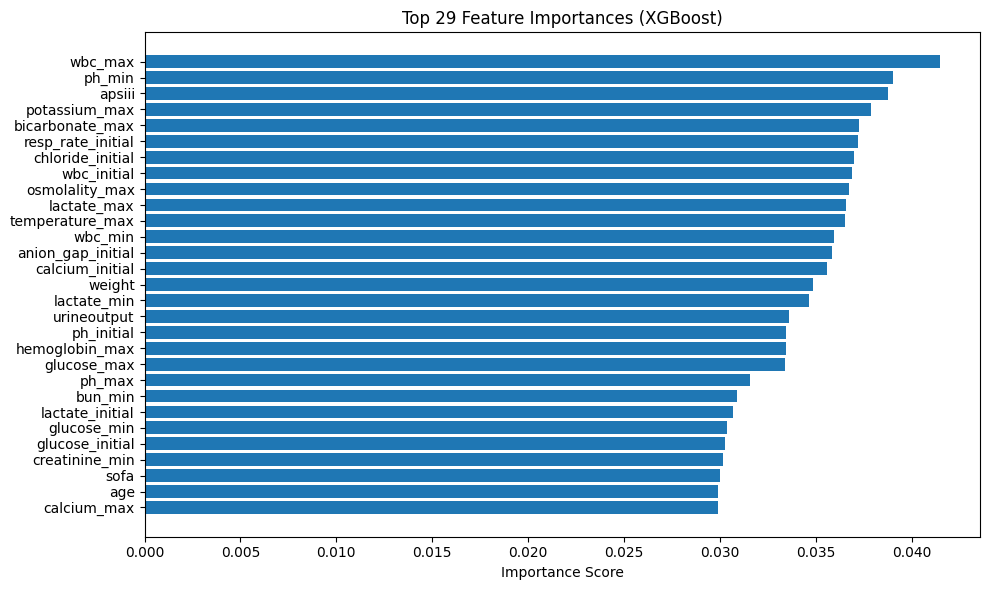

Feature importance plot saved
Genarating SHAP explanations...
SHAP explanations generated and saved.
Generating LIME explanations...


In [24]:
importlib.reload(XGBoost_XAI)
print("----------- SYNTHETIC DATA NO SHAP, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------")
no_pre_feat_imp_df, feat_imp_grouped, feature_importance_shap = XGBoost_XAI.get_feature_importance(
    syn_shap_None,
    "C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/img/shap/",
    'syn_shap_None'
)

#### Synthetic data, 10 SHAP penalty. Robustness test

----------- SYNTHETIC DATA SHAP 10 A, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------
Num of train data: 1099. Num of test data: 472
Train Outcome: in_hospital_death
0    1052
1      47
Name: count, dtype: int64
Test Outcome: in_hospital_death
0    452
1     20
Name: count, dtype: int64
Training XGBoost model...
Model trained successfully.
Evaluating model...
Accuracy: 0.93
Sensitivity: 0.05
Specificity: 0.97
True Negative: 439 False Positive: 13 False Negative: 19 True Positive: 1
AUC: 0.58
AUPRC (Average Precision): 0.06
Precision: 0.07
F1 Score: 0.06


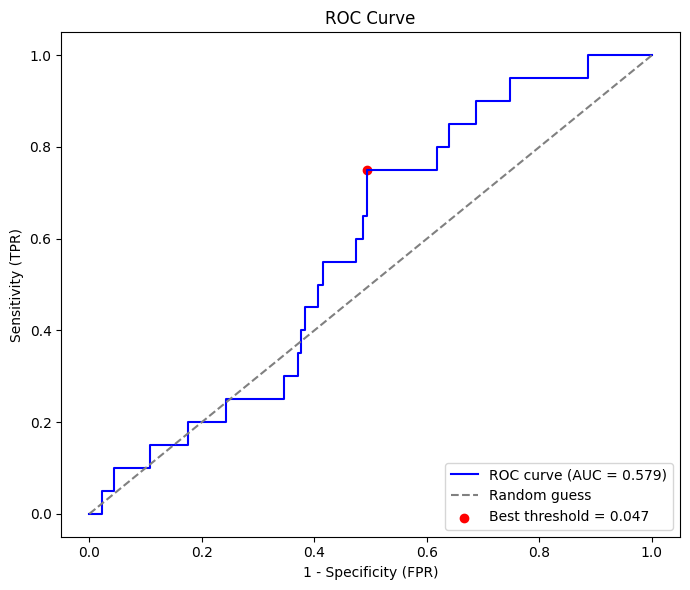

Optimal Threshold: 0.047
Accuracy: 0.52
Sensitivity: 0.75
Specificity: 0.51
True Negative: 229 False Positive: 223 False Negative: 5 True Positive: 15
Precision: 0.06
F1 Score: 0.12


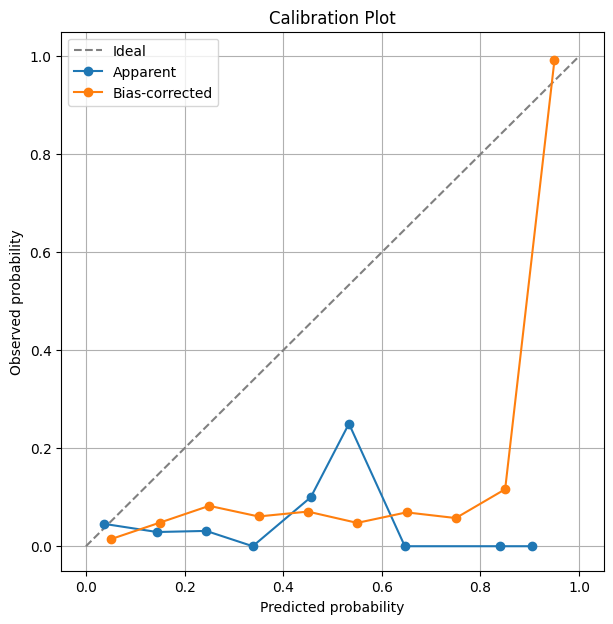

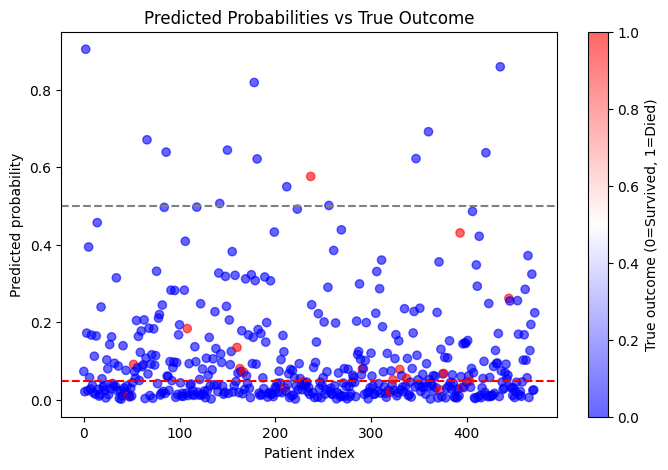

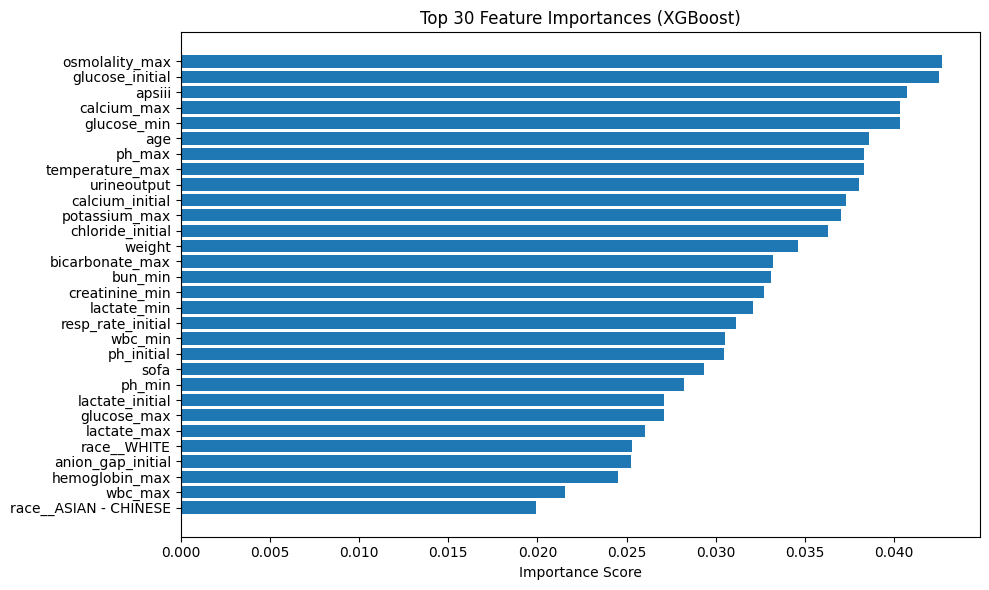

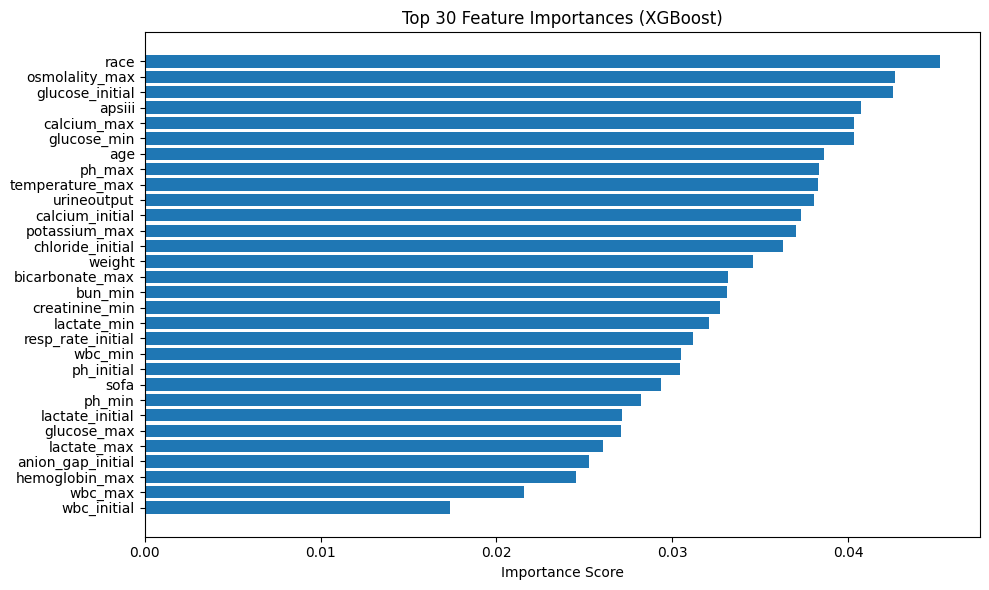

Feature importance plot saved
Genarating SHAP explanations...
SHAP explanations generated and saved.
Generating LIME explanations...
----------- SYNTHETIC DATA SHAP 10 B, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------
Num of train data: 1099. Num of test data: 472
Train Outcome: in_hospital_death
0    1037
1      62
Name: count, dtype: int64
Test Outcome: in_hospital_death
0    445
1     27
Name: count, dtype: int64
Training XGBoost model...
Model trained successfully.
Evaluating model...
Accuracy: 0.93
Sensitivity: 0.04
Specificity: 0.98
True Negative: 436 False Positive: 9 False Negative: 26 True Positive: 1
AUC: 0.56
AUPRC (Average Precision): 0.08
Precision: 0.10
F1 Score: 0.05


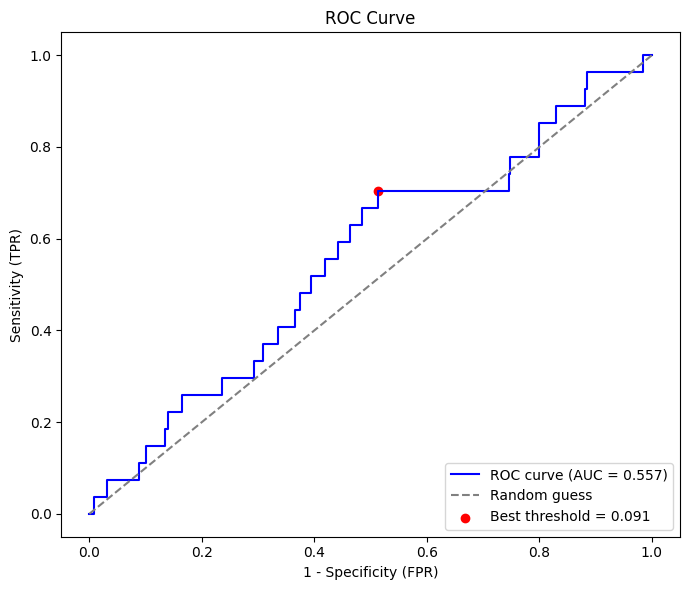

Optimal Threshold: 0.091
Accuracy: 0.50
Sensitivity: 0.70
Specificity: 0.49
True Negative: 217 False Positive: 228 False Negative: 8 True Positive: 19
Precision: 0.08
F1 Score: 0.14


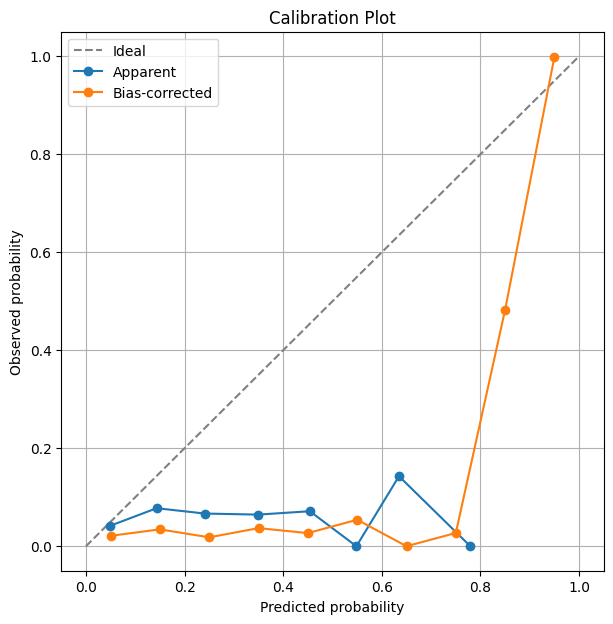

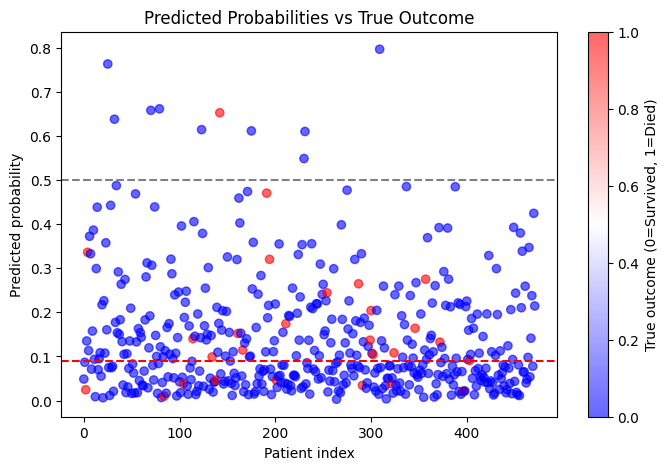

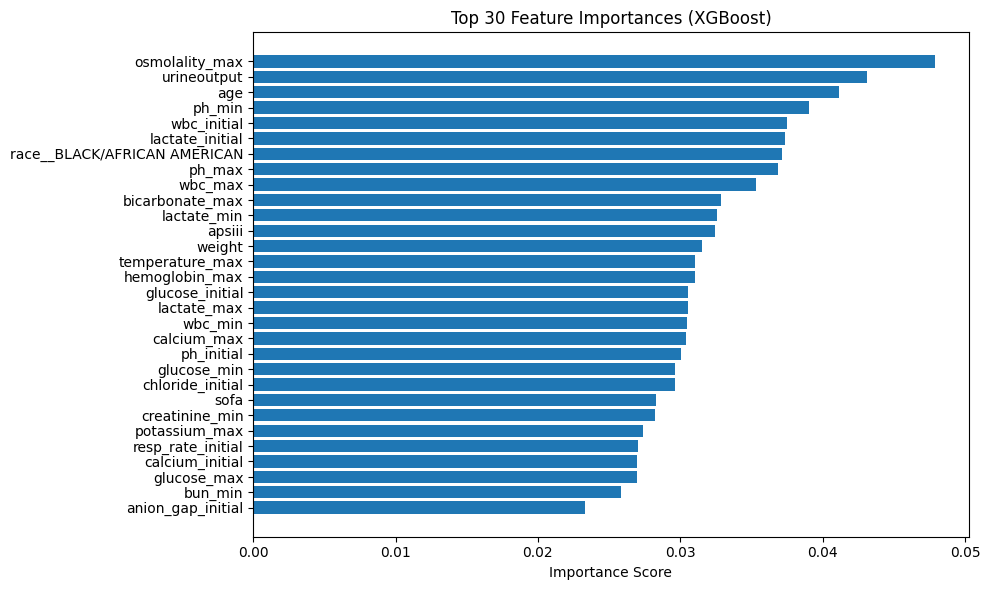

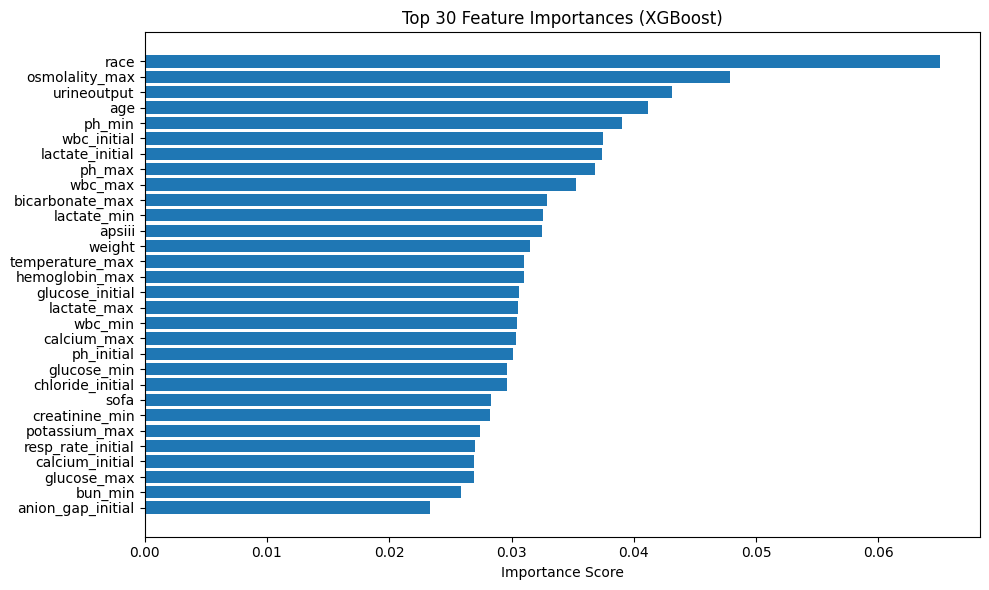

Feature importance plot saved
Genarating SHAP explanations...
SHAP explanations generated and saved.
Generating LIME explanations...


In [3]:
importlib.reload(XGBoost_XAI)
syn_shap_10_a = pd.read_csv("C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/output/syn_data_shap_10.csv")
syn_shap_10_b = pd.read_csv("C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/output/syn_data_shap_10_b.csv")
print("----------- SYNTHETIC DATA SHAP 10 A, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------")
feat_imp_df_a, feat_imp_grouped_a, feat_imp_shap_a, feat_imp_shap_gr_a = XGBoost_XAI.get_feature_importance(
    syn_shap_10_a,
    "C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/img/10_shap/",
    'syn_shap_10_a'
)
print("----------- SYNTHETIC DATA SHAP 10 B, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------")
feat_imp_df_b, feat_imp_grouped_b, feat_imp_shap_b, feat_imp_shap_gr_b = XGBoost_XAI.get_feature_importance(
    syn_shap_10_b,
    "C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/img/10_shap/",
    'syn_shap_10_b'
)

In [ ]:
from scipy.stats import spearmanr

# 1. Make sure features are aligned across real, A and B
merged_A = feat_imp_shap_gr_real.merge(
    feat_imp_shap_gr_a,
    on="feature",
    suffixes=("_real", "_A")
)

merged_B = feat_imp_shap_gr_real.merge(
    feat_imp_shap_gr_b,
    on="feature",
    suffixes=("_real", "_B")
)

merged_AB = feat_imp_shap_gr_a.merge(
    feat_imp_shap_gr_b,
    on="feature",
    suffixes=("_A", "_B")
)

# 2. Extract the importance values as 1D arrays
real_vals_A = merged_A["importance_real"]
A_vals      = merged_A["importance_A"]

real_vals_B = merged_B["importance_real"]
B_vals      = merged_B["importance_B"]

A_vals_AB = merged_AB["importance_A"]
B_vals_AB = merged_AB["importance_B"]

# 3. Spearman correlations
rho_A, pA   = spearmanr(real_vals_A, A_vals)
rho_B, pB   = spearmanr(real_vals_B, B_vals)
rho_AB, pAB = spearmanr(A_vals_AB, B_vals_AB)

print("Real vs A:  rho =", rho_A, "p =", pA)
print("Real vs B:  rho =", rho_B, "p =", pB)
print("A vs B:     rho =", rho_AB, "p =", pAB)


RMSE (Root Mean Squared Error)

What it measures: The average magnitude of difference between two sets of Shapley values (e.g., from two different training runs).
Why it matters: If you retrain the model and the Shapley values change drastically, the explanations are unstable. RMSE quantifies this instability.
Interpretation:

Low RMSE: Shapley values are consistent across runs → good robustness.
High RMSE: Large variation in feature importance → poor robustness.


Formula:
RMSE=1n∑i=1n(Si(1)−Si(2))2\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(S_i^{(1)} - S_i^{(2)})^2}RMSE=n1​∑i=1n​(Si(1)​−Si(2)​)2​
where Si(1)S_i^{(1)}Si(1)​ and Si(2)S_i^{(2)}Si(2)​ are Shapley values for feature iii in two runs.

In [ ]:
from sklearn.metrics import root_mean_squared_error
rmse_A = root_mean_squared_error(real_vals_A, A_vals)
rmse_B = root_mean_squared_error(real_vals_B, B_vals)
rmse_AB = root_mean_squared_error(A_vals_AB, B_vals_AB)
print("Real vs A:  RMSE =", rmse_A)
print("Real vs B:  RMSE =", rmse_B)
print("A vs B:     RMSE =", rmse_AB)


#### Synthetic data, 0.15 SHAP penalty

----------- SYNTHETIC DATA 0.15*SHAP, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------
Num of train data: 1099. Num of test data: 472
Train Outcome: in_hospital_death
0    1054
1      45
Name: count, dtype: int64
Test Outcome: in_hospital_death
0    452
1     20
Name: count, dtype: int64
Training XGBoost model...
Model trained successfully.
Evaluating model...
Accuracy: 0.94
Sensitivity: 0.10
Specificity: 0.97
True Negative: 440 False Positive: 12 False Negative: 18 True Positive: 2
AUC: 0.50
AUPRC (Average Precision): 0.08
Precision: 0.14
F1 Score: 0.12


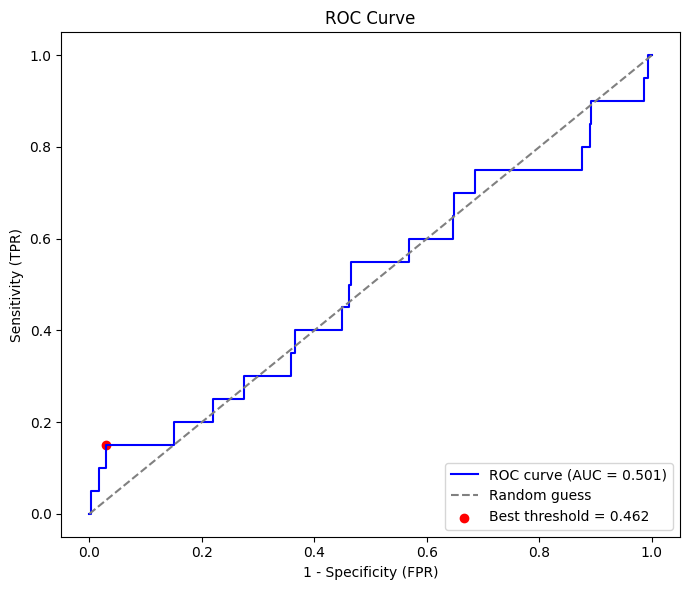

Optimal Threshold: 0.462
Accuracy: 0.94
Sensitivity: 0.15
Specificity: 0.97
True Negative: 439 False Positive: 13 False Negative: 17 True Positive: 3
Precision: 0.19
F1 Score: 0.17


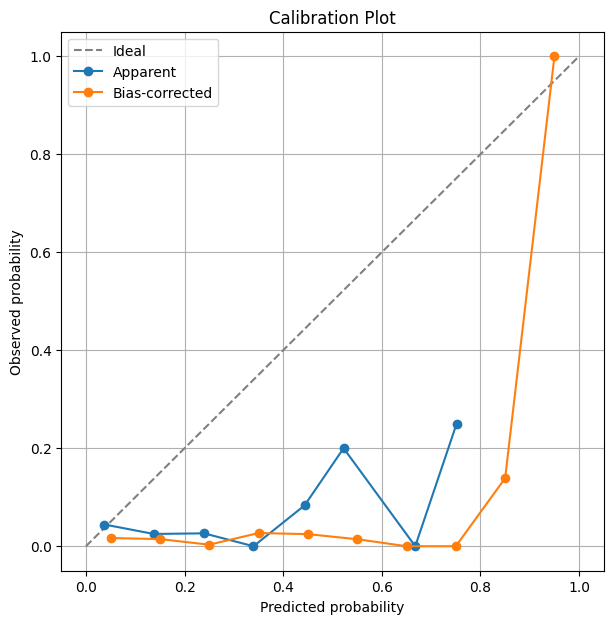

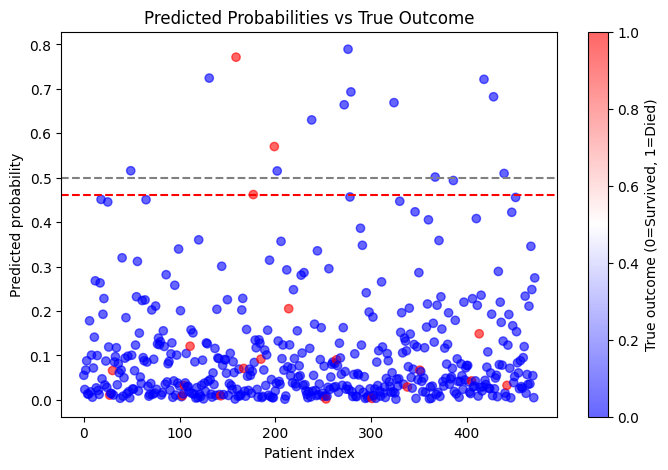

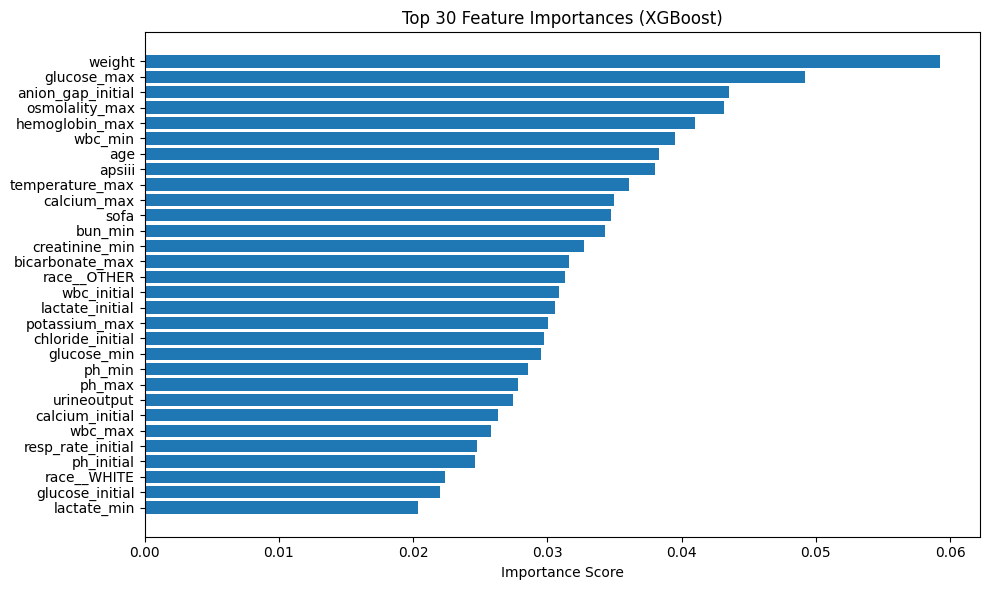

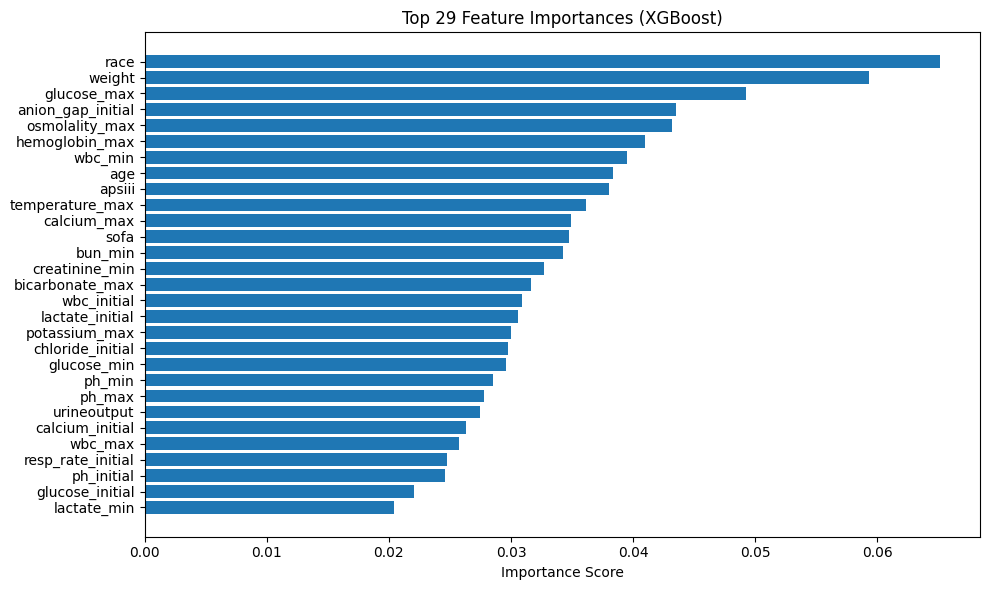

Feature importance plot saved
Genarating SHAP explanations...
SHAP explanations generated and saved.
Generating LIME explanations...


In [25]:
importlib.reload(XGBoost_XAI)
print("----------- SYNTHETIC DATA 0.15*SHAP, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------")
no_pre_feat_imp_df, feat_imp_grouped, feature_importance_shap = XGBoost_XAI.get_feature_importance(
    syn_shap_015,
    "C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/img/shap/",
    'syn_shap_015'
)

#### Synthetic data, 0.30 SHAP penalty

----------- SYNTHETIC DATA 0.30*SHAP, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------
Num of train data: 1099. Num of test data: 472
Train Outcome: in_hospital_death
0    1036
1      63
Name: count, dtype: int64
Test Outcome: in_hospital_death
0    445
1     27
Name: count, dtype: int64
Training XGBoost model...
Model trained successfully.
Evaluating model...
Accuracy: 0.90
Sensitivity: 0.15
Specificity: 0.95
True Negative: 423 False Positive: 22 False Negative: 23 True Positive: 4
AUC: 0.56
AUPRC (Average Precision): 0.08
Precision: 0.15
F1 Score: 0.15


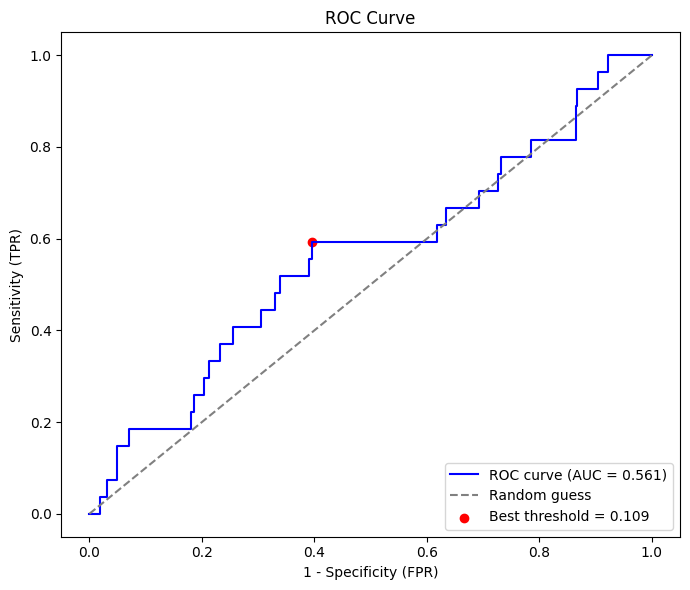

Optimal Threshold: 0.109
Accuracy: 0.60
Sensitivity: 0.59
Specificity: 0.60
True Negative: 269 False Positive: 176 False Negative: 11 True Positive: 16
Precision: 0.08
F1 Score: 0.15


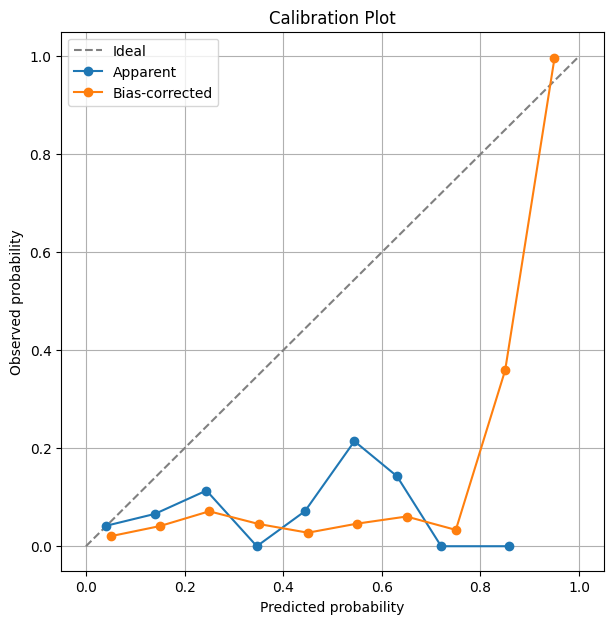

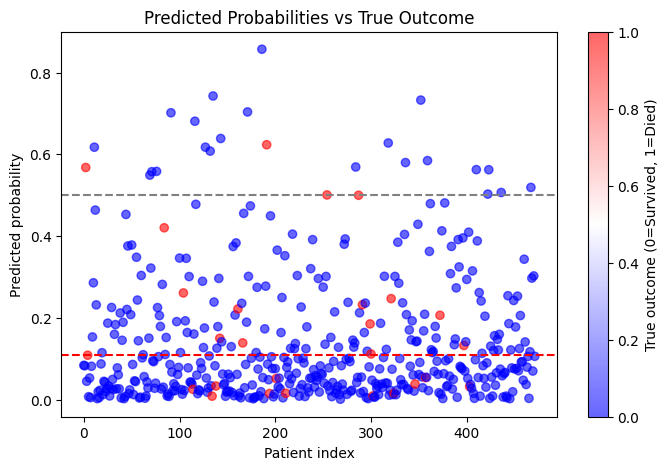

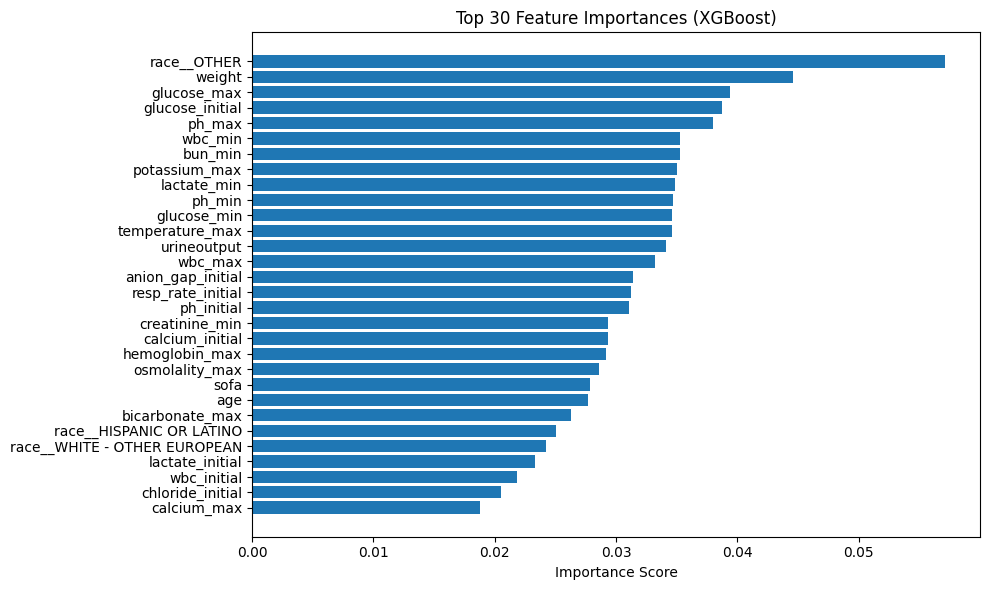

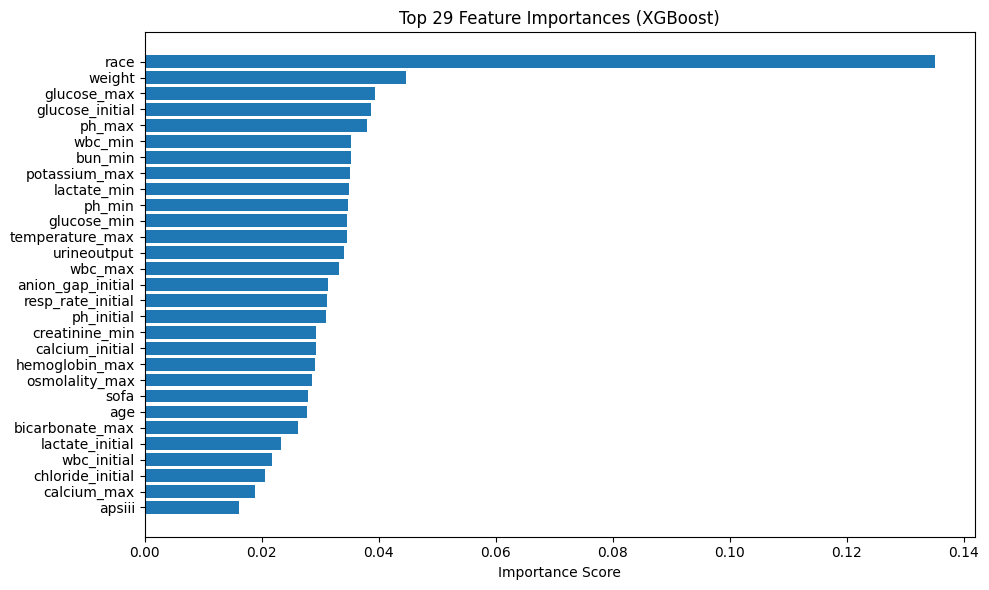

Feature importance plot saved
Genarating SHAP explanations...
SHAP explanations generated and saved.
Generating LIME explanations...


In [26]:
importlib.reload(XGBoost_XAI)
print("----------- SYNTHETIC DATA 0.30*SHAP, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------")
no_pre_feat_imp_df, feat_imp_grouped, feature_importance_shap = XGBoost_XAI.get_feature_importance(
    syn_shap_030,
    "C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/img/shap/",
    'syn_shap_030'
)

#### Synthetic data, 1 SHAP penalty

----------- SYNTHETIC DATA 1*SHAP, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------
Num of train data: 1099. Num of test data: 472
Train Outcome: in_hospital_death
0    1046
1      53
Name: count, dtype: int64
Test Outcome: in_hospital_death
0    449
1     23
Name: count, dtype: int64
Training XGBoost model...
Model trained successfully.
Evaluating model...
Accuracy: 0.91
Sensitivity: 0.00
Specificity: 0.96
True Negative: 431 False Positive: 18 False Negative: 23 True Positive: 0
AUC: 0.57
AUPRC (Average Precision): 0.06
Precision: 0.00
F1 Score: 0.00


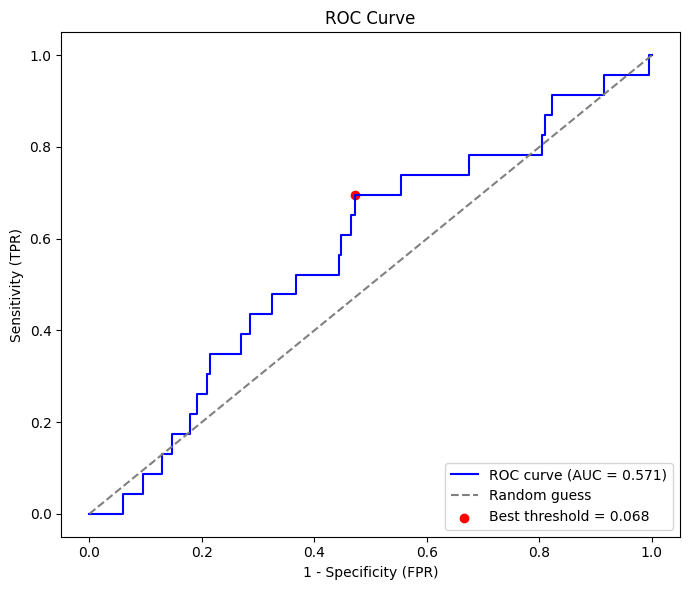

Optimal Threshold: 0.068
Accuracy: 0.54
Sensitivity: 0.70
Specificity: 0.53
True Negative: 237 False Positive: 212 False Negative: 7 True Positive: 16
Precision: 0.07
F1 Score: 0.13


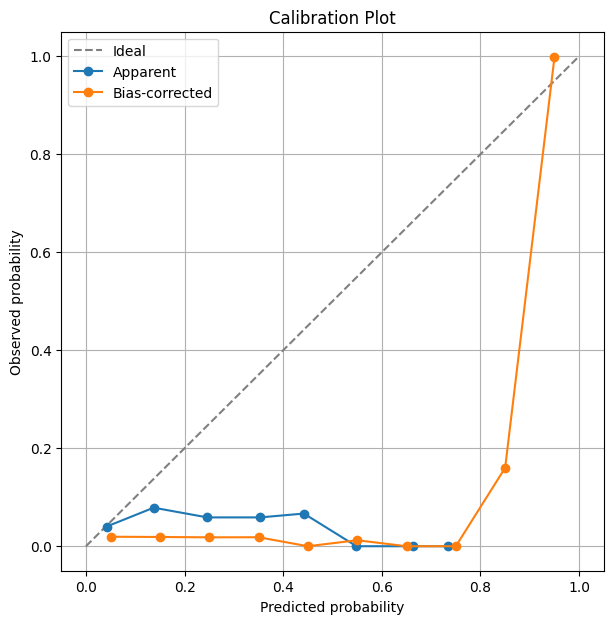

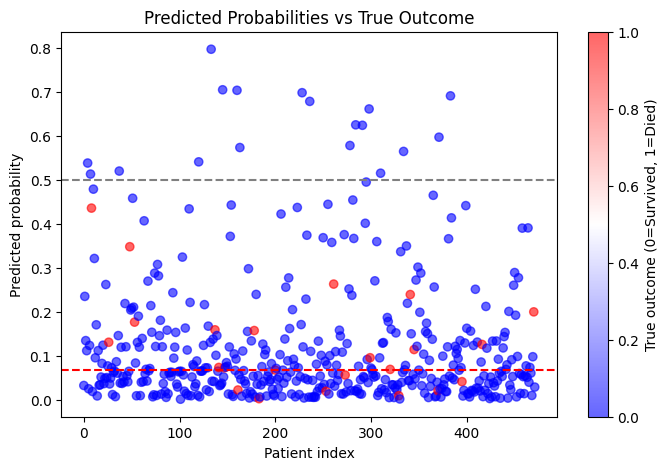

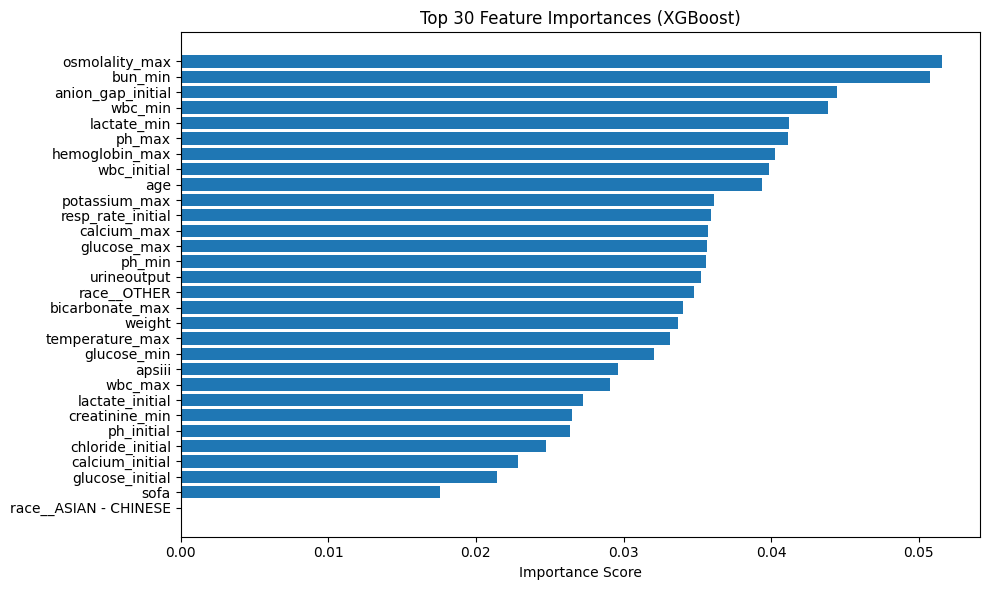

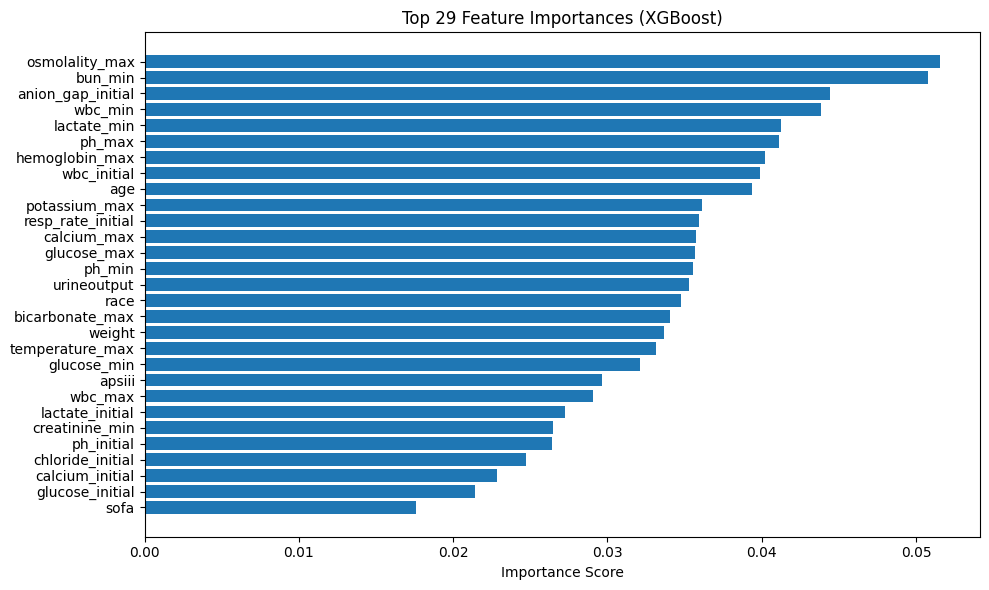

Feature importance plot saved
Genarating SHAP explanations...
SHAP explanations generated and saved.
Generating LIME explanations...


In [27]:
importlib.reload(XGBoost_XAI)
print("----------- SYNTHETIC DATA 1*SHAP, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------")
no_pre_feat_imp_df, feat_imp_grouped, feature_importance_shap = XGBoost_XAI.get_feature_importance(
    syn_shap_1,
    "C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/img/shap/",
    'syn_shap_1'
)

#### Synthetic data, 5 SHAP penalty, no race

----------- SYNTHETIC DATA 5*SHAP No race, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------
Num of train data: 1099. Num of test data: 472
Train Outcome: in_hospital_death
0    865
1    234
Name: count, dtype: int64
Test Outcome: in_hospital_death
0    372
1    100
Name: count, dtype: int64
Training XGBoost model...
Model trained successfully.
Evaluating model...
Accuracy: 0.67
Sensitivity: 0.23
Specificity: 0.78
True Negative: 292 False Positive: 80 False Negative: 77 True Positive: 23
AUC: 0.48
AUPRC (Average Precision): 0.21
Precision: 0.22
F1 Score: 0.23


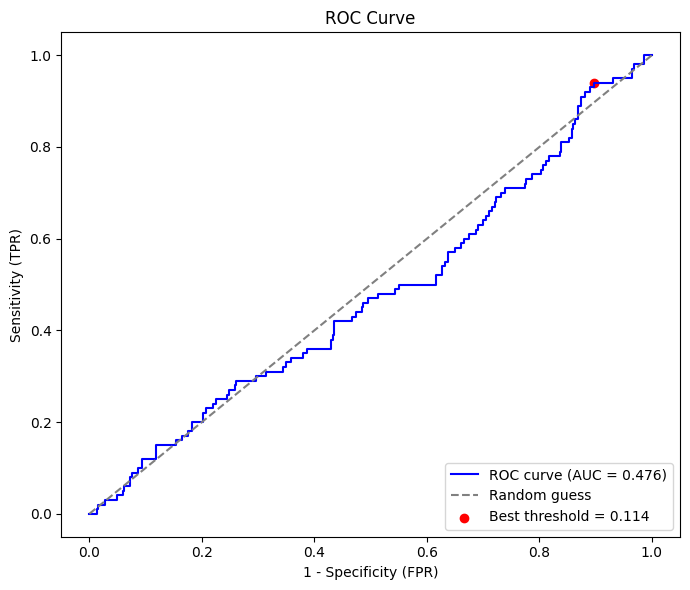

Optimal Threshold: 0.114
Accuracy: 0.28
Sensitivity: 0.94
Specificity: 0.10
True Negative: 38 False Positive: 334 False Negative: 6 True Positive: 94
Precision: 0.22
F1 Score: 0.36


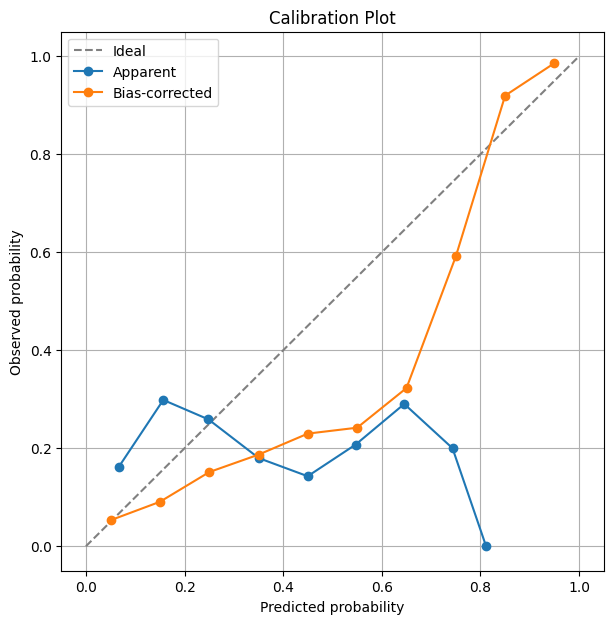

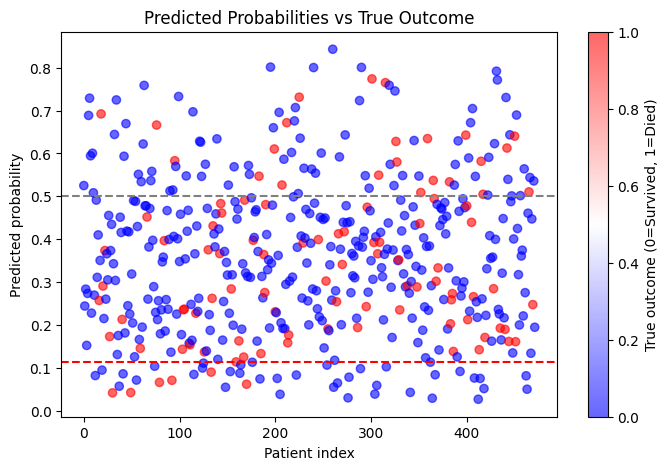

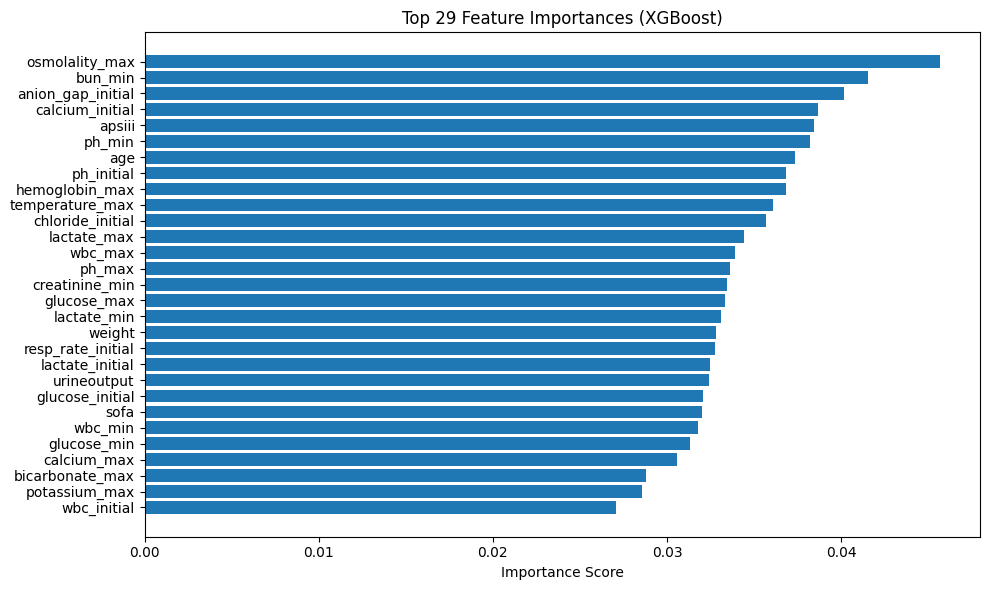

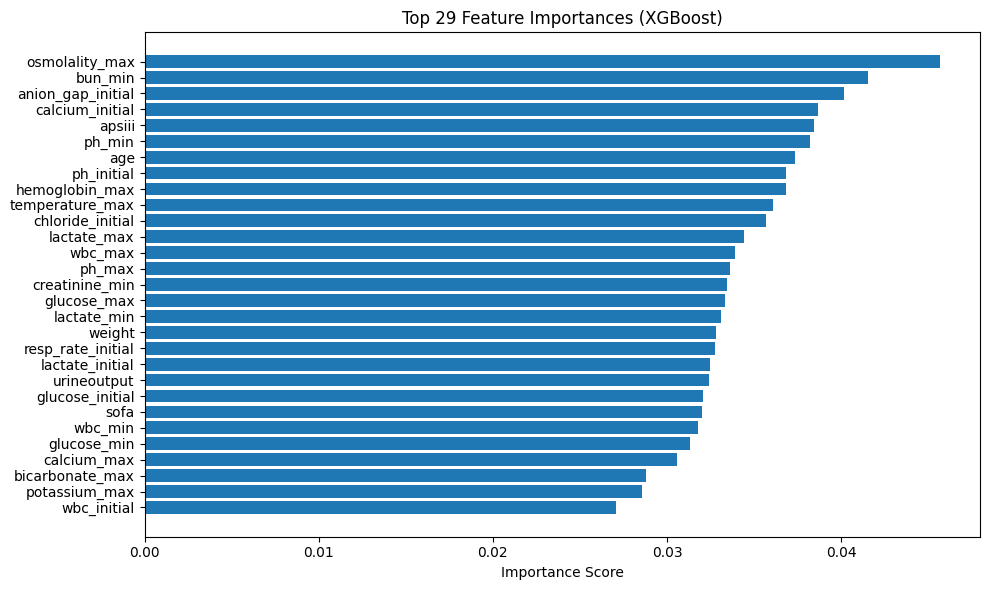

Feature importance plot saved
Genarating SHAP explanations...
SHAP explanations generated and saved.
Generating LIME explanations...


In [ ]:
importlib.reload(XGBoost_XAI)
print("----------- SYNTHETIC DATA 5*SHAP No race, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------")
no_pre_feat_imp_df, feat_imp_grouped, feature_importance_shap = XGBoost_XAI.get_feature_importance(
    syn_shap_nr_5,
    "C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/img/shap/",
    'syn_shap_nr_5'
)

#### Synthetic data, 10 SHAP penalty, per patient

In [ ]:
importlib.reload(XGBoost_XAI)
print("----------- SYNTHETIC DATA 10*SHAP, SHAP_IMPORTANCE FEATURES 30: Getting feature importance...-----------")
syn_shap_10_pp = pd.read_csv("C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/output/2025_11_24_11_57_45_syn_data_shap_10_per_patient.csv")
feat_imp, feat_imp_gr, feat_imp_shap_gr = XGBoost_XAI.get_feature_importance(
    syn_shap_10_pp,
    "C:/Users/maria/Code/master/xai-synthetic-health/dp_cgans/tests/results/img/10_shap/",
    'syn_shap_10_per_patient'
)

# SHAP

In [56]:
import numpy as np
import shap

In [96]:
tree_explainer = shap.TreeExplainer(model_xgb_top)
shap_values = tree_explainer.shap_values(X_train_top_scaled)

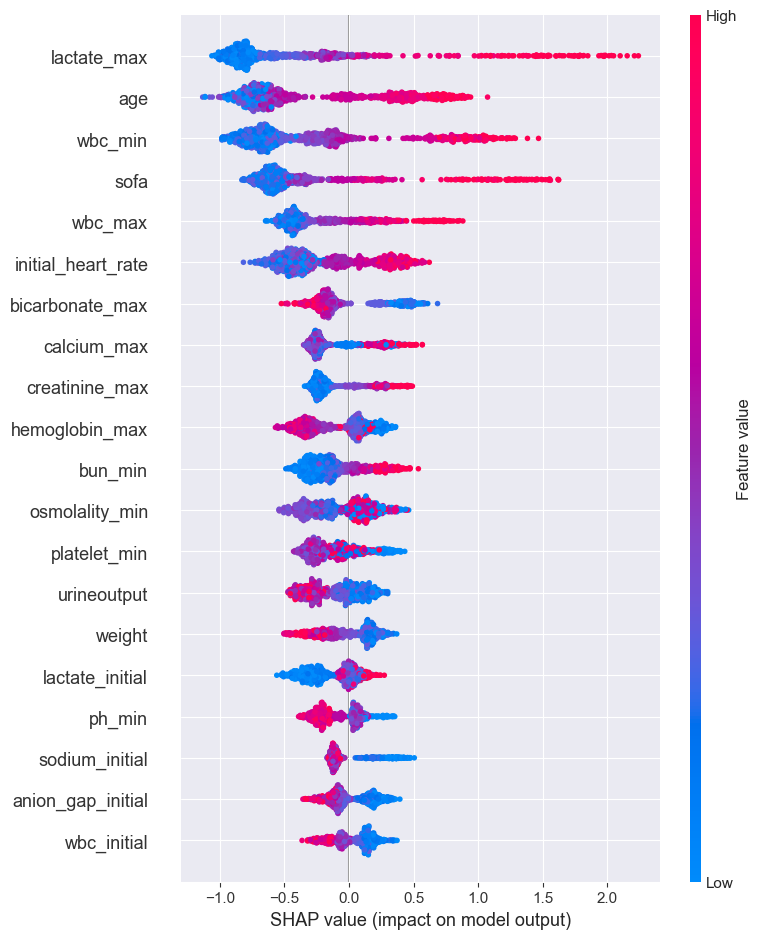

In [97]:
shap.summary_plot(shap_values, X_train_top_scaled, feature_names=top_features)

In [98]:
# Explain model
explainer = shap.Explainer(model_xgb_top)
shap_values = explainer(X_train_top)

In [99]:
np.shape(shap_values.values)

(1099, 40)

## Waterfall plot

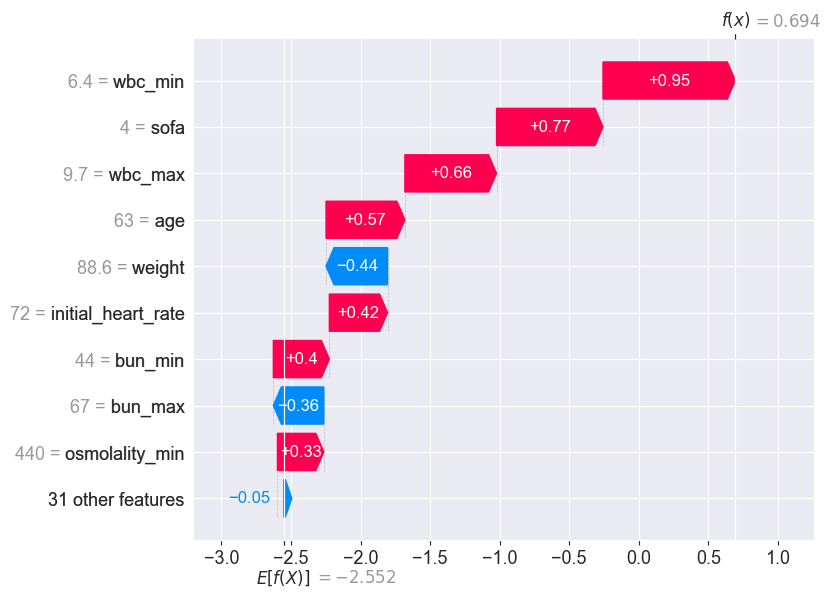

In [100]:
# for the 1st observation
shap.plots.waterfall(shap_values[0])

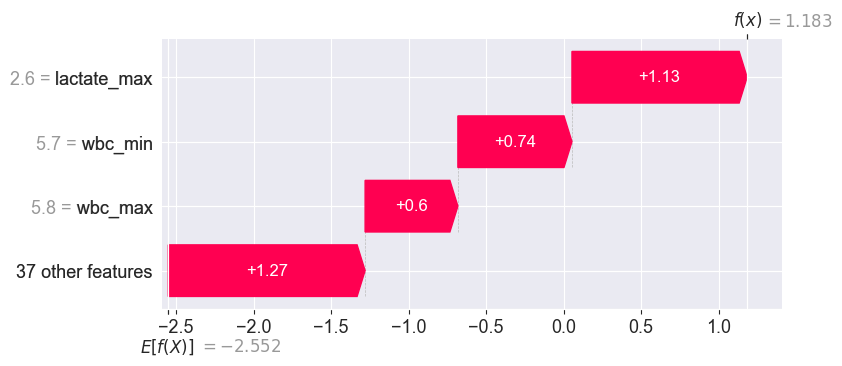

In [101]:
shap.plots.waterfall(shap_values[1], max_display=4)

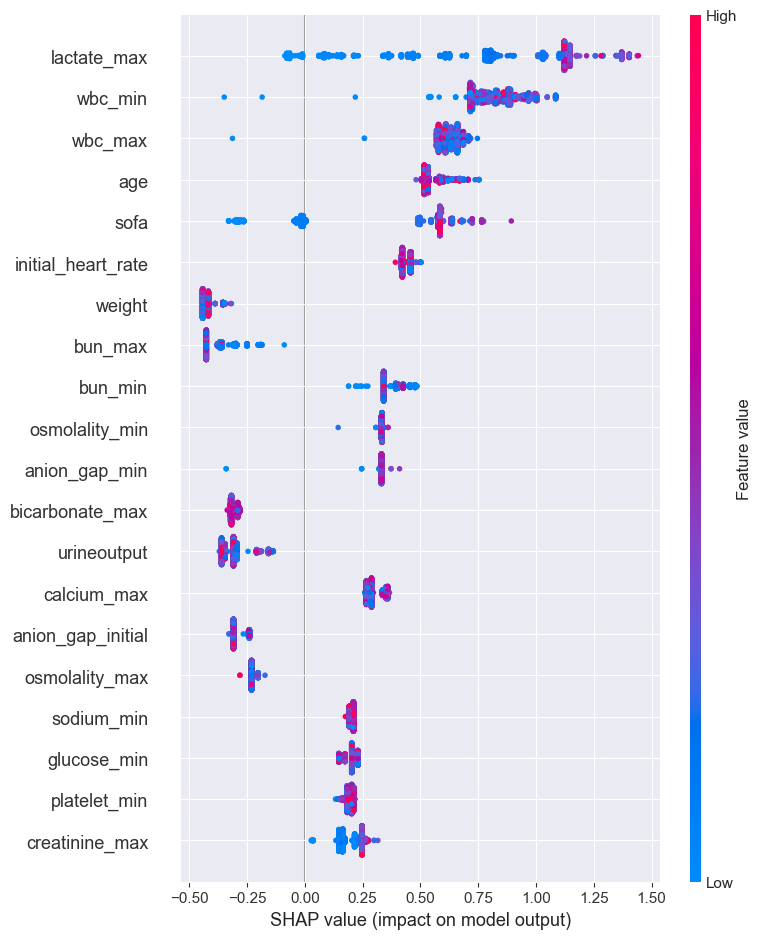

In [102]:
shap.summary_plot(shap_values, X_train_top, plot_type="dot")

In [86]:
## Force plot

In [139]:
shap.plots.force(shap_values[0])
shap.plots.force(shap_values[0:100]) 

## Absolute Mean SHAP
Which features are more important to the model.

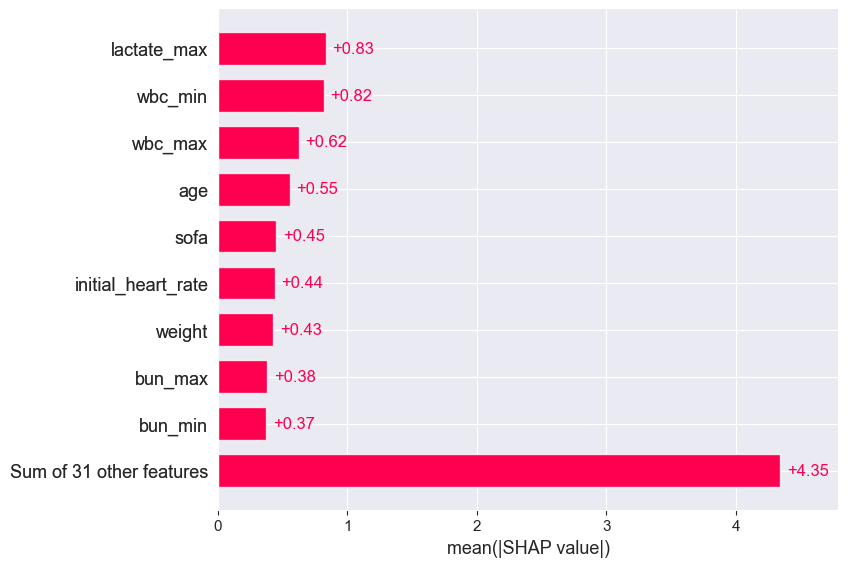

In [103]:
shap.plots.bar(shap_values)

## Beeswarm plot
All of the shap values.

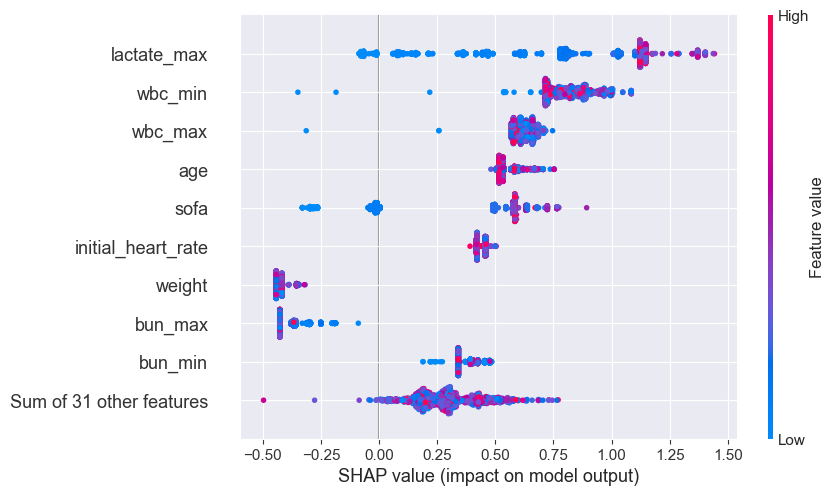

In [104]:
shap.plots.beeswarm(shap_values)

## Dependence plots

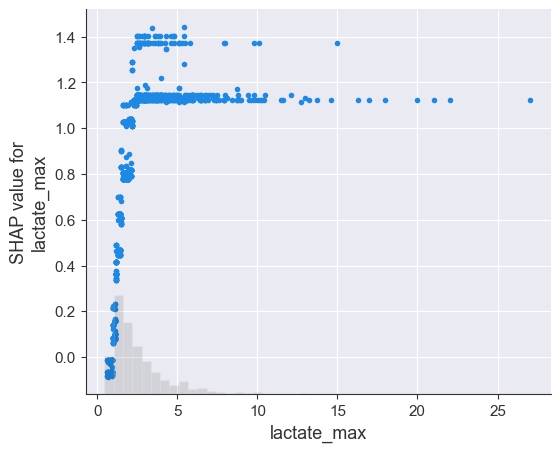

In [105]:
shap.plots.scatter(shap_values[:, 'lactate_max'])

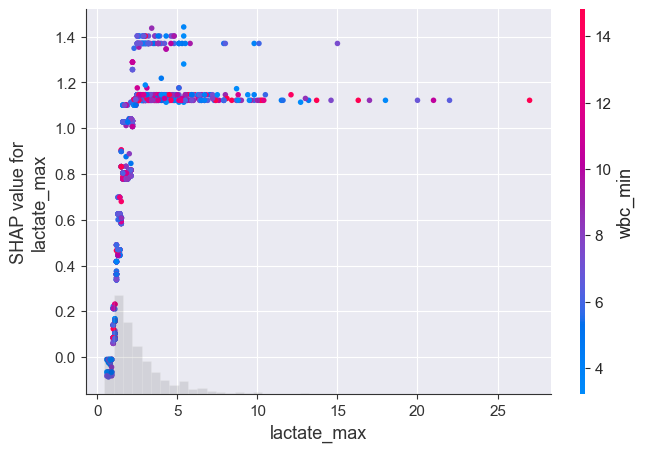

In [106]:
shap.plots.scatter(shap_values[:, 'lactate_max'], color=shap_values[:, 'wbc_min'])

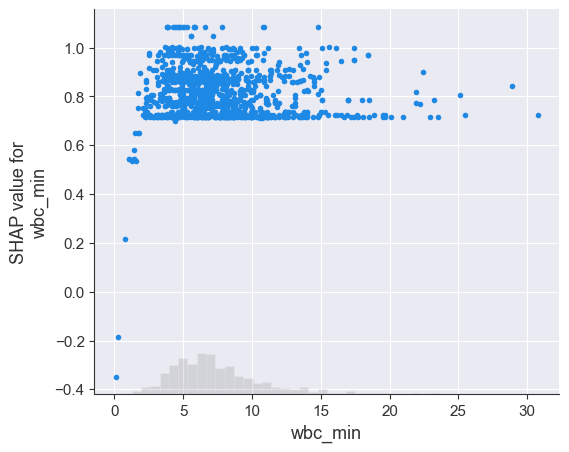

In [107]:
shap.plots.scatter(shap_values[:, 'wbc_min'])

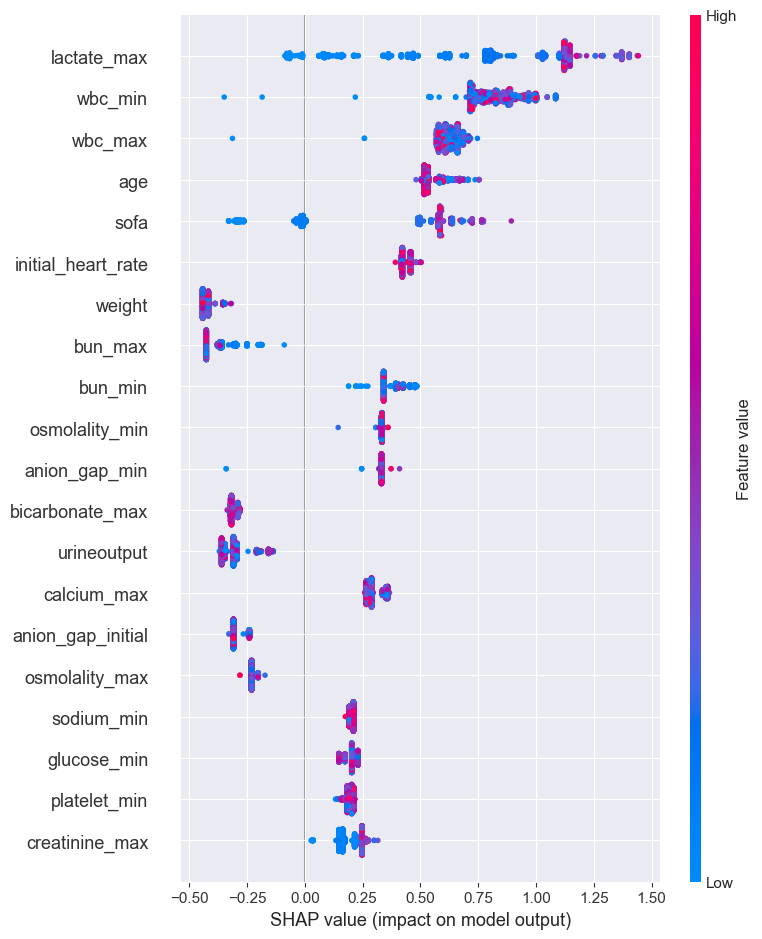

In [108]:
shap.summary_plot(shap_values, X_train_top)

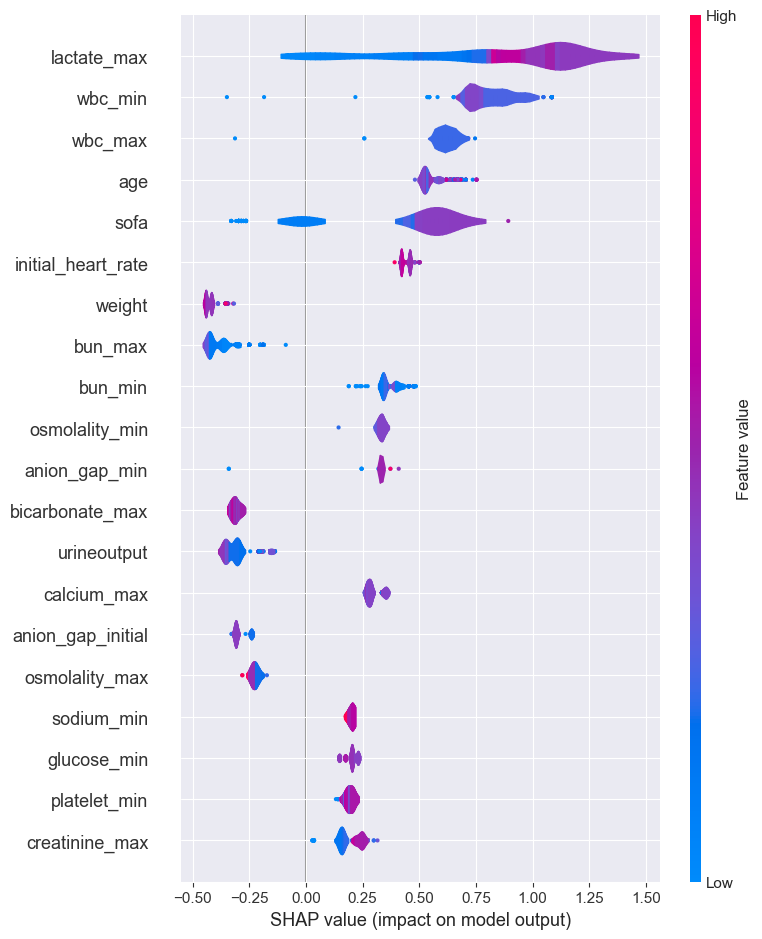

In [109]:
shap.summary_plot(shap_values, X_train_top, plot_type="violin", feature_names=X_train_top.columns)

Feature Interaction Detection with SHAP: Revealing Complex Dependencies Between Variables: https://medium.com/@lfoster49203/feature-interaction-detection-with-shap-revealing-complex-dependencies-between-variables-ecab7ff4dbc2

# LIME

In [110]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=X_train.values,  # Use normalized data for explanation
    feature_names=X_train.columns,
    mode='classification',
    class_names=['0', '1'],  # Adjust based on your target
    discretize_continuous=False,  # Disable discretization to test
    feature_selection='auto',
    random_state=42
)

# Select an instance to explain
instance_idx = 0  # Adjust to your desired instance
instance = X_train.iloc[instance_idx].values  # Use normalized instance

# Get LIME explanation
exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=lambda x: model_xgb.predict_proba(X_train_normalized.iloc[x.index].values if isinstance(x, pd.Series) else x),  # Adjust predict_fn
    num_features=min(10, len(X_train.columns))
)

# Visualize the explanation
exp.show_in_notebook()  # For Jupyter notebook
exp.as_pyplot_figure()
plt.title(f"LIME Explanation for Instance {instance_idx}")
plt.tight_layout()
plt.show()

# Print data info
print("X_train shape:", X_train.shape)
print("X_train dtypes:\n", X_train.dtypes)
print("X_train sample:\n", X_train.head())

ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\maria\Code\master\dp_cgans\dp_cgans_env\Lib\site-packages\IPython\core\display.py)

In [5]:
paper_features = [
        'apsiii', 'lactate_max', 'age', 'sofa', 'urineoutput', 'creatinine_max', 'wbc_max', 'bun_max',
        'temperature_max', 'calcium_max', 'chloride_max', 'los', 'ph_max', 'mbp_min', 'weight', 'hemoglobin_min',
        'platelet_min', 'osmolality_min', 'sodium_max', 'potassium_max', 'calcium_min', 'osmolality_max',
        'resp_rate_max', 'glucose_max', 'heart_rate_max', 'ph_min', 'vasopressor', 'cardiac_disease',
        'osmolality_initial', 'in_hospital_death']

top_40 = [
    'race', 'sofa', 'lactate_max', 'vasopressor', 'age', 'wbc_min', 'diabetes_without_cc',
    'bun_min', 'calcium_max', 'potassium_initial', 'lactate_initial',
    'wbc_max', 'creatinine_min', 'osmolality_initial', 'apsiii', 'temperature_max',
    'creatinine_max', 'potassium_min', 'bicarbonate_initial', 'lactate_min', 'bun_initial', 'bicarbonate_max',
    'anion_gap_max', 'chloride_initial', 'osmolality_max', 'wbc_initial', 'bicarbonate_min', 'weight', 'ph_min',
    'platelet_max', 'bun_max', 'potassium_max', 'resp_rate_initial', 'glucose_initial', 'sodium_max',
    'calcium_min', 'anion_gap_min', 'hemoglobin_max', 'mbp_initial', 'gcs', 'in_hospital_death']

print(len(paper_features))
print(len(top_40[:30]))


30
30


In [9]:
i = 0
j = 0
for f in top_40:
    if f not in paper_features :
        i+=1
        print(f)
    else:
        j+=1

print(f"Common {j} and not in top_40 {i}")


race
wbc_min
diabetes_without_cc
bun_min
potassium_initial
lactate_initial
creatinine_min
potassium_min
bicarbonate_initial
lactate_min
bun_initial
bicarbonate_max
anion_gap_max
chloride_initial
wbc_initial
bicarbonate_min
platelet_max
resp_rate_initial
glucose_initial
anion_gap_min
hemoglobin_max
mbp_initial
gcs
Common 18 and not in top_40 23
